# Amazon Sales Data Analysis — Exploratory Data Analysis

Explores the Amazon products dataset through data cleaning, feature engineering, summary statistics, and visualizations to examine patterns related to monthly sales.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("amazon_products.csv")
df.head()


,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


In [2]:
# Initial summary of key numeric fields
df[['purchased_last_month', 'discounted_price']].describe()


,purchased_last_month,discounted_price
count,32164.000000,40613.000000
mean,1293.665278,243.227289
std,6318.323574,473.351545
min,50.000000,2.160000
25%,100.000000,29.690000
50%,200.000000,84.990000
75%,400.000000,224.000000
max,100000.000000,5449.000000


In [3]:
missing_counts = df.isna().sum()

print("Missing values per column:")
print(missing_counts)

print("\nTotal missing values in dataset:", missing_counts.sum())

Missing values per column:
product_title               0
product_rating           1024
total_reviews            1024
purchased_last_month    10511
discounted_price         2062
original_price           2062
is_best_seller              0
is_sponsored                0
has_coupon                  0
buy_box_availability    14653
delivery_date           11983
sustainability_tags     39267
product_image_url           0
product_page_url         2069
data_collected_at           0
product_category            0
discount_percentage      2062
dtype: int64

Total missing values in dataset: 86717


In [4]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Number of duplicate rows: 0
Duplicate rows after removal: 0
New dataset shape: (42675, 17)


In [5]:
df = df.rename(columns={'purchased_last_month': 'monthly_sales'})

In [6]:
df['product_category'] = df['product_category'].astype('category')

In [7]:
df['price_difference'] = df['original_price'] - df['discounted_price']

df[['original_price', 'discounted_price', 'price_difference']].head()

,original_price,discounted_price,price_difference
0,159.00,89.68,69.32
1,15.99,9.99,6.00
2,349.00,314.00,35.00
3,162.24,162.24,0.00
4,72.74,72.74,0.00


In [8]:
df_sponsored = df[df['is_sponsored'] == True]
df_not_sponsored = df[df['is_sponsored'] == False]

print("Number of sponsored products:", df_sponsored.shape[0])
print("Number of non-sponsored products:", df_not_sponsored.shape[0])

Number of sponsored products: 0
Number of non-sponsored products: 0


In [9]:
df[['monthly_sales', 'discounted_price']].describe()

,monthly_sales,discounted_price
count,32164.000000,40613.000000
mean,1293.665278,243.227289
std,6318.323574,473.351545
min,50.000000,2.160000
25%,100.000000,29.690000
50%,200.000000,84.990000
75%,400.000000,224.000000
max,100000.000000,5449.000000


In [10]:
# Create price bands for comparison across pricing levels
df['price_group'] = pd.qcut(df['discounted_price'], q=4, duplicates='drop')
print(df['product_category'].value_counts().head(10))
df['price_group'].value_counts().sort_index()


product_category
Other Electronics    8755
Laptops              8693
Phones               6563
Cameras              3677
Power & Batteries    2877
TV & Display         2630
Chargers & Cables    1833
Storage              1630
Speakers             1345
Networking           1070
Name: count, dtype: int64


price_group
(2.1590000000000003, 29.69]    10272
(29.69, 84.99]                 10040
(84.99, 224.0]                 10221
(224.0, 5449.0]                10080
Name: count, dtype: int64

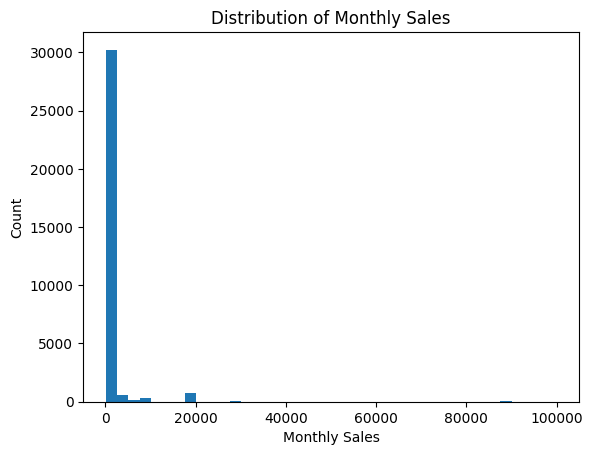

In [11]:
#This histogram shows the distribution of monthly sales across all products. The distribution is skewed to the right. This histogram shows that certain product characteristics may strongly influence higher sales performance.
plt.hist(df['monthly_sales'], bins=40)
plt.title("Distribution of Monthly Sales")
plt.xlabel("Monthly Sales")
plt.ylabel("Count")
plt.show()

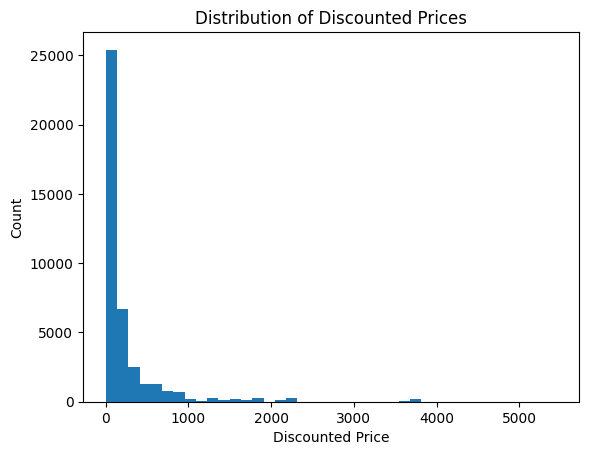

In [12]:
#This histogram shows the distribution of discounted prices. The distribution is normal. Understanding that is important because knowing how pircing can affect sales.
plt.hist(df['discounted_price'], bins=40)
plt.title("Distribution of Discounted Prices")
plt.xlabel("Discounted Price")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1444/2217664203.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_sponsored['monthly_sales'],


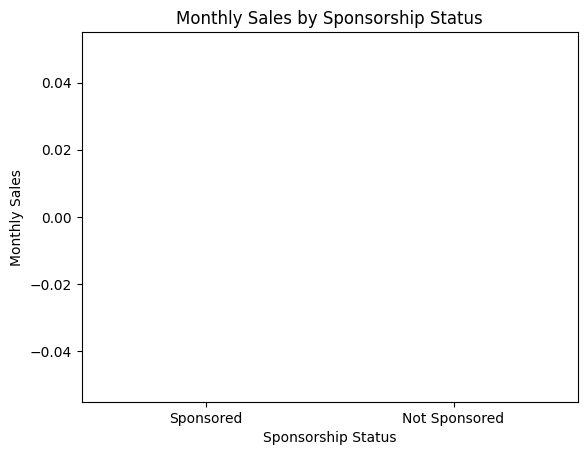

In [13]:
#This boxplot compares monthly sales between sponsored and non-sponsored products. If the median for sponsored products is higher, this suggests sponsorship may be associated with higher sales. Vice Versa. indicating that a small number of products achieve very high sales.
plt.boxplot([df_sponsored['monthly_sales'],
             df_not_sponsored['monthly_sales']],
            labels=['Sponsored', 'Not Sponsored'])

plt.title("Monthly Sales by Sponsorship Status")
plt.xlabel("Sponsorship Status")
plt.ylabel("Monthly Sales")
plt.show()

/tmp/ipykernel_1444/1005959734.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=df['price_group'].cat.categories)


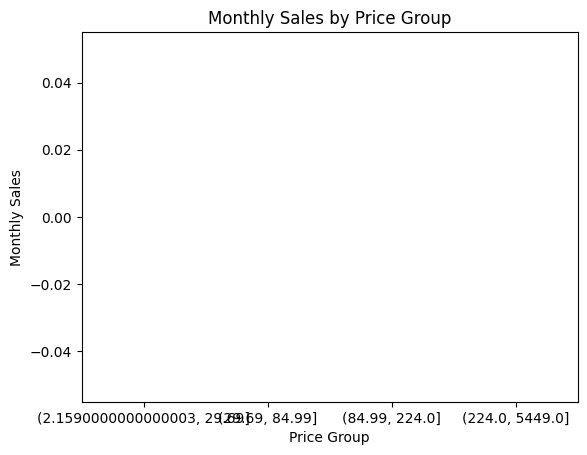

In [14]:
#This boxplot shows how monthly sales vary across different price groups. The differences in median sales and distribution patterns across price groups suggest that some pricing levels are associated with higher sales. Helps find a strategy to influence consumers purchasing behavior.
groups = [df[df['price_group']==g]['monthly_sales'] 
          for g in df['price_group'].cat.categories]

plt.boxplot(groups, labels=df['price_group'].cat.categories)
plt.title("Monthly Sales by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Monthly Sales")
plt.show()

/tmp/ipykernel_1444/3790863830.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('product_category')['monthly_sales'] \


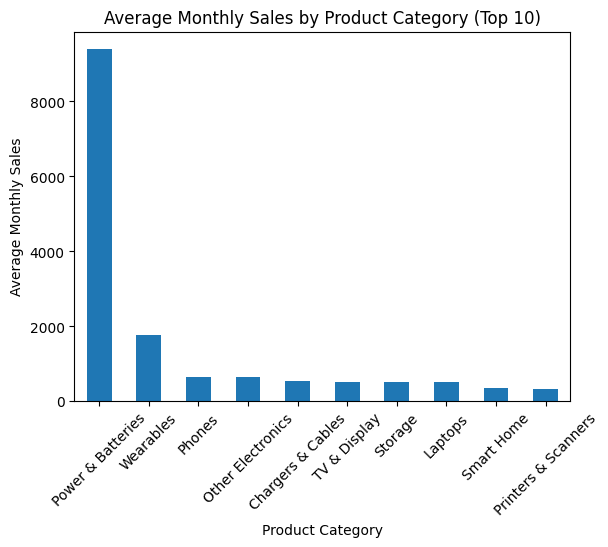

In [15]:
#This bar chart shows the average monthly sales for the top product categories. The Different bar heights indicate that some categories generate higher average sales than others. Suggests that product category may influence consumer demand and overall sales performance.
df.groupby('product_category')['monthly_sales'] \
  .mean().sort_values(ascending=False).head(10) \
  .plot(kind='bar')

plt.title("Average Monthly Sales by Product Category (Top 10)")
plt.xlabel("Product Category")
plt.ylabel("Average Monthly Sales")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1444/3496917726.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_group')['monthly_sales'].mean().plot(kind='bar')


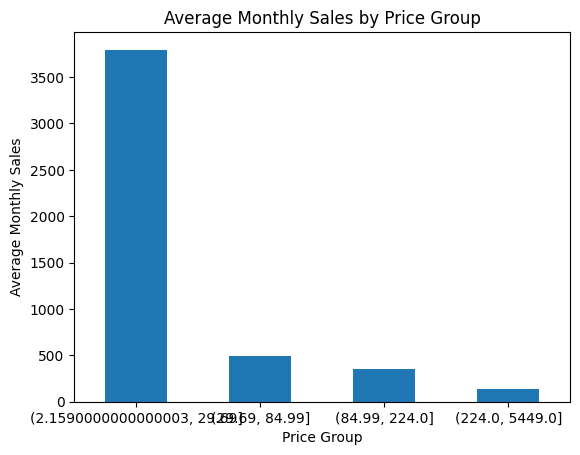

In [16]:
#This bar chart compares the average monthly sales across price groups. The variation in average sales across price groups suggests that pricing levels may influence overall sales performance. If lower price groups show higher average sales, Consumers are more sensitive to lower prices, which directly relates to the research hypotheses about pricing and sales.
df.groupby('price_group')['monthly_sales'].mean().plot(kind='bar')

plt.title("Average Monthly Sales by Price Group")
plt.xlabel("Price Group")
plt.ylabel("Average Monthly Sales")
plt.xticks(rotation=0)
plt.show()